# TB4: Eval first predictions

**Started:** August 18, 2026

**Last updated:** August 26, 2026

**Research questions:** Does IMPACT-OR better predict human LT-HSC responses to BCG vaccination than scGen in terms of feature-wise r^2 and pathway-level trends seen in the human BCG publication?

**Hypothesis:**

**Conclusion:**

**Potential Next Steps:**


**Eval notes**

Load mouse BCG (scANVI-mapped), human BCG (scANVI-mapped), and mouse→human **scGen** / **IMPACT-CellOT** predictions (control + treated), then embed them together on one UMAP in shared atlas ENSG / 1000-HVG space.

**Pathway analysis:** 14 MSigDB Hallmark sets (OXPHOS → KRAS Signaling Dn; see `PATHWAYS`) for **mouse, human, scGen, and IMPACT-CellOT**. Always use **human** Hallmark gene sets → ENSG (GTF). Mouse objects are already on the human ENSG / atlas-HVG axis (one2one ortholog projection upstream). Module scores via `sc.tl.score_genes`; Mann–Whitney untreated vs treated per source.

**Kernel:** `speciesOT_env`


## Paths

Edit the strings in the next cell. The rest of the notebook reads from these variables.

In [30]:
# --- edit these filepath strings ---

impactor_control_path = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/bcg_ctrl_081826_predicted_human_via_impact_cellot_pearson_residuals_uncapped_v08_iid.h5ad"
impactor_treated_path = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/bcg_trt_081826_predicted_human_via_impact_cellot_pearson_residuals_uncapped_v08_iid.h5ad"
scgen_control_path = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/bcg_ctrl_081826_predicted_human_via_scgen_pearson_residuals_uncapped_v08_iid.h5ad"
scgen_treated_path = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/bcg_trt_081826_predicted_human_via_scgen_pearson_residuals_uncapped_v08_iid.h5ad"

mouse_control_path = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/mouse_bcg/bcg_control_scanvi_081826.h5ad"
mouse_treated_path = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/mouse_bcg/bcg_treated_scanvi_081826.h5ad"
human_control_path = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_control_scanvi_082626.h5ad"
human_treated_path = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_treated_scanvi_082626.h5ad"

ORTHO_CACHE = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/scripts/.biomart_ortholog_cache.csv"
GTF_PATH = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/human_ref/refdata-gex-GRCh38-2020-A/genes/genes.gtf"
HALLMARK_PATH = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/MSigDB_Hallmark_2020.txt"
HALLMARK_URL = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=MSigDB_Hallmark_2020"

PATHWAYS = [
    ("oxphos", "Oxidative Phosphorylation"),
    ("tnfa_nfkb", "TNF-alpha Signaling via NF-kB"),
    ("hypoxia", "Hypoxia"),
    ("ros", "Reactive Oxygen Species Pathway"),
    ("apoptosis", "Apoptosis"),
    ("allograft", "Allograft Rejection"),
    ("il2_stat5", "IL-2/STAT5 Signaling"),
    ("myc_v1", "Myc Targets V1"),
    ("myc_v2", "Myc Targets V2"),
    ("dna_repair", "DNA Repair"),
    ("emt", "Epithelial Mesenchymal Transition"),
    ("uv_up", "UV Response Up"),
    ("heme", "heme Metabolism"),
    ("kras_dn", "KRAS Signaling Dn"),
]

PATHWAY_SOURCES = ["mouse", "human", "scgen", "impact_cellot"]


In [31]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import issparse

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, figsize=(5, 5), frameon=False)
np.random.seed(0)

DATASET_PATHS = {
    ("mouse", "control"): mouse_control_path,
    ("mouse", "treated"): mouse_treated_path,
    ("human", "control"): human_control_path,
    ("human", "treated"): human_treated_path,
    ("impact_cellot", "control"): impactor_control_path,
    ("impact_cellot", "treated"): impactor_treated_path,
    ("scgen", "control"): scgen_control_path,
    ("scgen", "treated"): scgen_treated_path,
}

adatas = {}  # all sources for UMAP
for (source, condition), path in DATASET_PATHS.items():
    p = Path(path)
    print(f"{source:14s} {condition:8s} exists={p.exists()}  {p.name}")
    if not p.exists():
        raise FileNotFoundError(path)
    a = sc.read_h5ad(path)
    a.var_names = [str(v).split(".")[0] if str(v).startswith("ENS") else str(v) for v in a.var_names]
    a.var_names_make_unique()
    a.obs["source"] = source
    a.obs["bcg_condition"] = condition
    a.obs["umap_group"] = f"{source} {condition}"
    if source in ("scgen", "impact_cellot"):
        a.obs["prediction_model"] = source
    adatas[(source, condition)] = a
    print(f"  {a.n_obs} cells x {a.n_vars} genes")


mouse          control  exists=True  bcg_control_scanvi_081826.h5ad
  387 cells x 1000 genes
mouse          treated  exists=True  bcg_treated_scanvi_081826.h5ad
  251 cells x 1000 genes
human          control  exists=True  bcg_control_scanvi_082626.h5ad
  230 cells x 1000 genes
human          treated  exists=True  bcg_treated_scanvi_082626.h5ad
  392 cells x 1000 genes
impact_cellot  control  exists=True  bcg_ctrl_081826_predicted_human_via_impact_cellot_pearson_residuals_uncapped_v08_iid.h5ad
  387 cells x 1000 genes
impact_cellot  treated  exists=True  bcg_trt_081826_predicted_human_via_impact_cellot_pearson_residuals_uncapped_v08_iid.h5ad
  251 cells x 1000 genes
scgen          control  exists=True  bcg_ctrl_081826_predicted_human_via_scgen_pearson_residuals_uncapped_v08_iid.h5ad
  387 cells x 1000 genes
scgen          treated  exists=True  bcg_trt_081826_predicted_human_via_scgen_pearson_residuals_uncapped_v08_iid.h5ad
  251 cells x 1000 genes


In [32]:
def _as_log_expression(adata: sc.AnnData) -> sc.AnnData:
    """Use counts→normalize→log1p when available; else keep .X (predictions)."""
    a = adata.copy()
    if "counts" in a.layers:
        a.X = a.layers["counts"].copy()
        sc.pp.normalize_total(a, target_sum=1e4)
        sc.pp.log1p(a)
    else:
        # Predicted objects are already on a continuous expression scale in .X
        if issparse(a.X):
            a.X = a.X.astype(np.float32)
        else:
            a.X = np.asarray(a.X, dtype=np.float32)
    return a


# Shared gene axis (intersection, atlas HVG order from first object)
gene_sets = [set(a.var_names) for a in adatas.values()]
shared_genes = set.intersection(*gene_sets)
ref_genes = [g for g in next(iter(adatas.values())).var_names if g in shared_genes]
print(f"Shared genes for joint UMAP: {len(ref_genes)}")

parts = []
for key, adata in adatas.items():
    a = _as_log_expression(adata)[:, ref_genes].copy()
    a.obs_names = [f"{key[0]}_{key[1]}_{i}" for i in a.obs_names.astype(str)]
    parts.append(a)

combined = ad.concat(parts, join="inner", merge="same")
combined.obs_names_make_unique()
combined.var["highly_variable"] = True

sc.pp.scale(combined, max_value=10)
sc.tl.pca(combined, n_comps=30, random_state=0)
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(combined, random_state=0)

print(combined.obs["umap_group"].value_counts())
combined


Shared genes for joint UMAP: 1000


/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


umap_group
human treated            392
mouse control            387
scgen control            387
impact_cellot control    387
impact_cellot treated    251
mouse treated            251
scgen treated            251
human control            230
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 2536 × 1000
    obs: 'cell_type', 'study', '_scvi_batch', 'source', 'bcg_condition', 'umap_group'
    var: 'highly_variable', 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

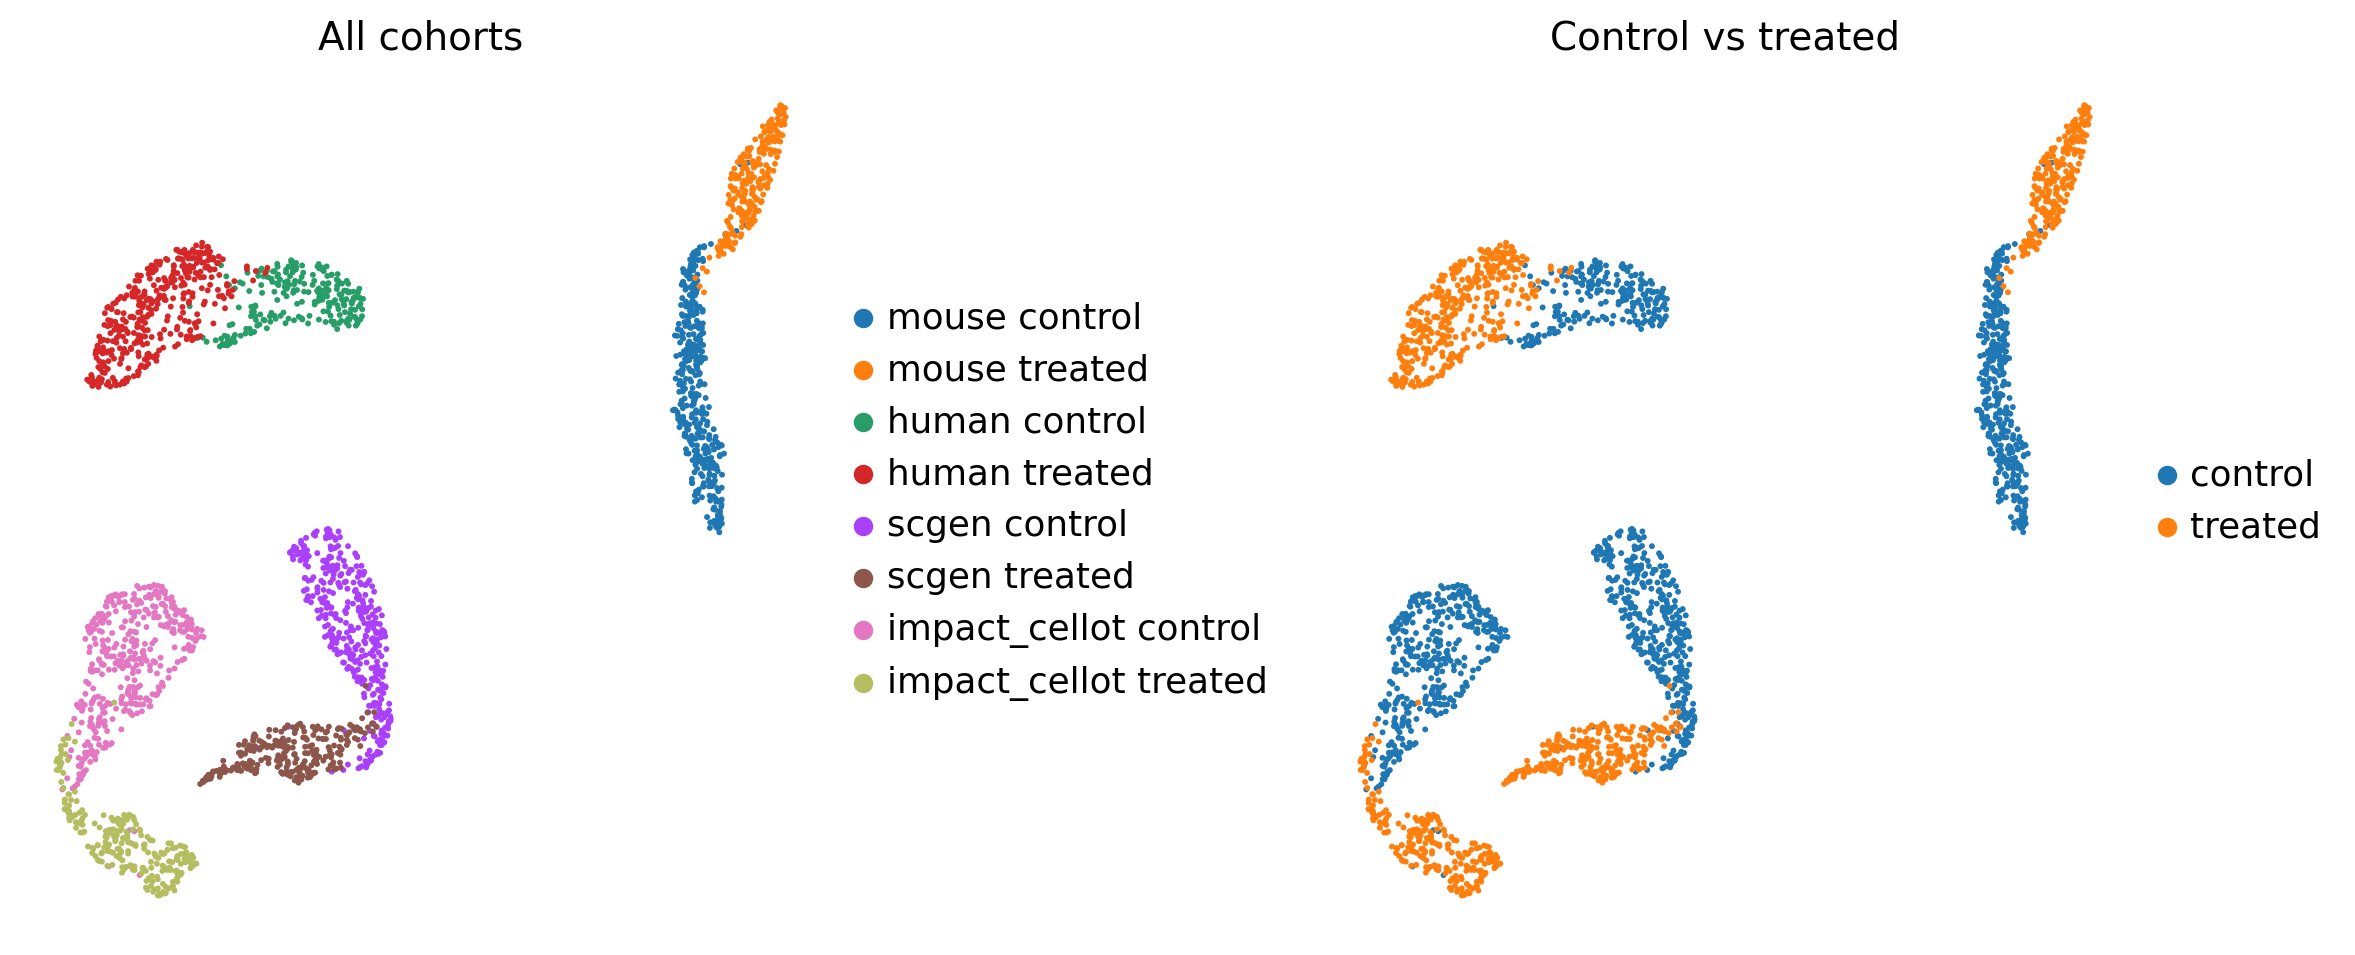

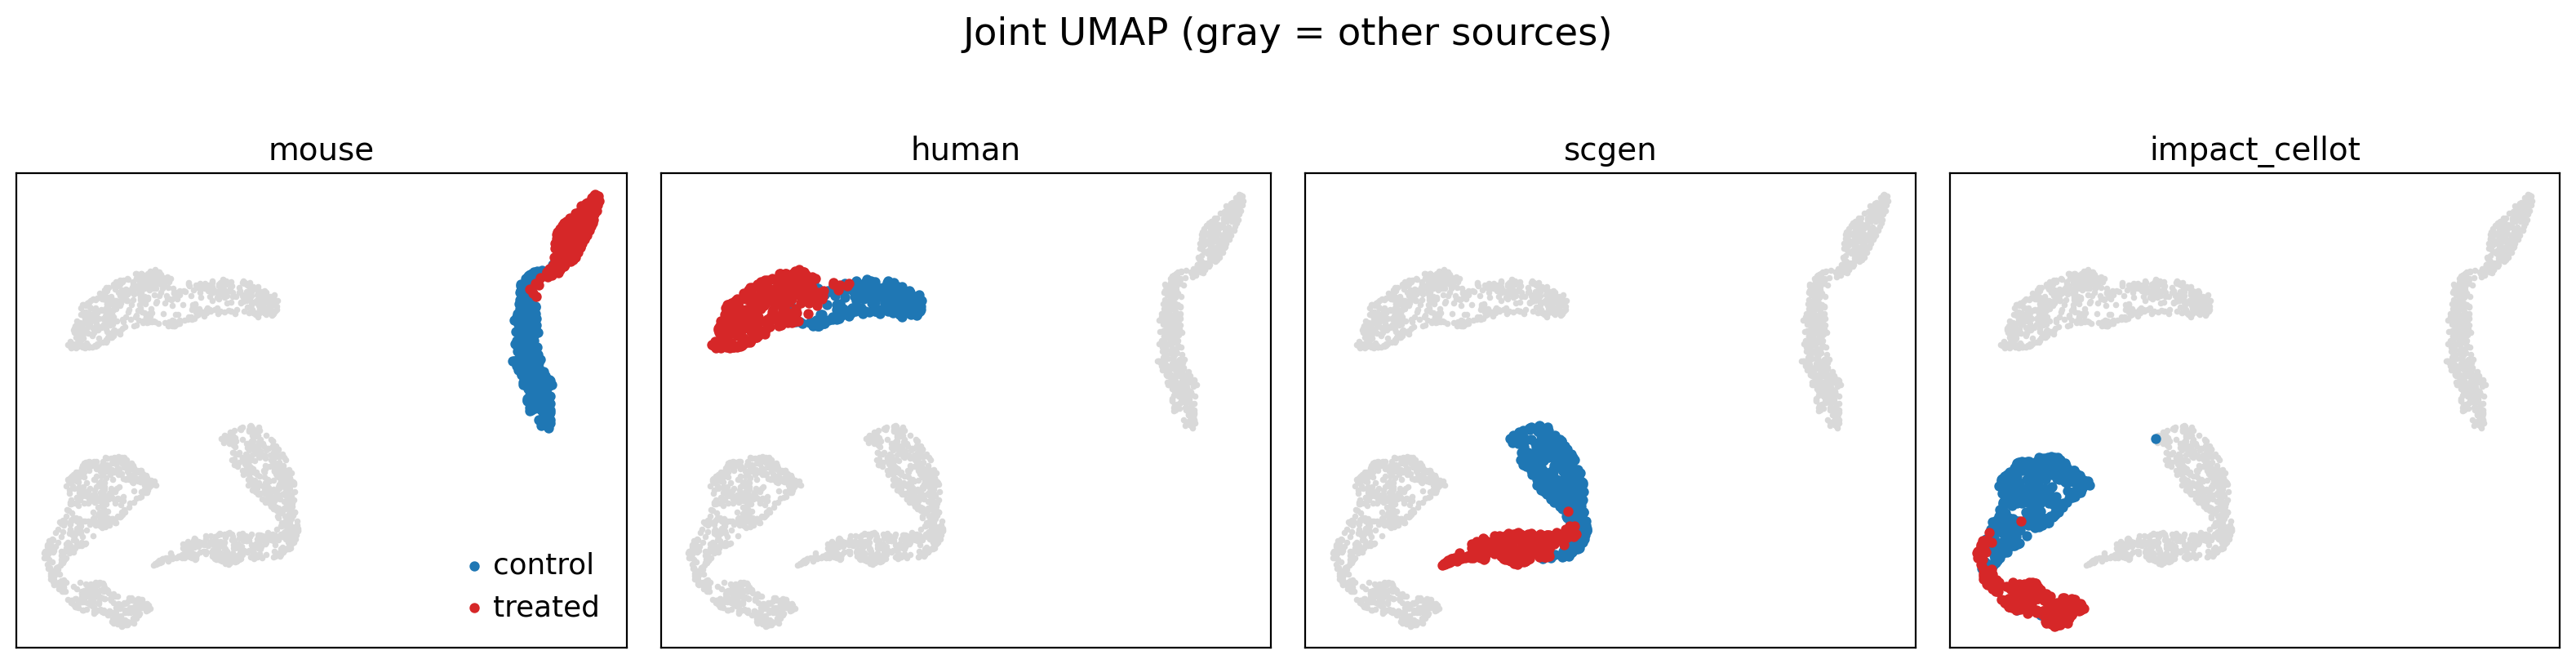

In [33]:
group_order = [
    "mouse control",
    "mouse treated",
    "human control",
    "human treated",
    "scgen control",
    "scgen treated",
    "impact_cellot control",
    "impact_cellot treated",
]
combined.obs["umap_group"] = pd.Categorical(
    combined.obs["umap_group"],
    categories=[g for g in group_order if g in set(combined.obs["umap_group"])],
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(combined, color="umap_group", ax=axes[0], show=False, size=18, title="All cohorts")
sc.pl.umap(combined, color="bcg_condition", ax=axes[1], show=False, size=18, title="Control vs treated")
fig.tight_layout()
plt.show()

# Facet by source for readability
sources = ["mouse", "human", "scgen", "impact_cellot"]
fig, axes = plt.subplots(1, len(sources), figsize=(16, 4), sharex=True, sharey=True)
coords = combined.obsm["X_umap"]
for ax, src in zip(axes, sources):
    mask = combined.obs["source"].astype(str) == src
    ax.scatter(coords[~mask, 0], coords[~mask, 1], s=3, c="0.85", rasterized=True)
    for cond, color in [("control", "#1f77b4"), ("treated", "#d62728")]:
        m = mask & (combined.obs["bcg_condition"].astype(str) == cond)
        ax.scatter(coords[m, 0], coords[m, 1], s=12, c=color, label=cond, rasterized=True)
    ax.set_title(src)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(frameon=False, loc="best")
fig.suptitle("Joint UMAP (gray = other sources)", y=1.02)
fig.tight_layout()
plt.show()


## Feature-wise $R^2$ vs human treated

Build a gene × condition table of **mean expression** (log-normalized from `counts` when available) for all 1000 atlas HVGs. Then compare mean profiles of **mouse treated**, **scGen treated**, **IMPACT-CellOT treated**, and **human untreated** against **human treated** with Pearson $r$ / $R^2$ across genes, plus scatter plots.


mean_expr: 1000 genes × 8 conditions


,mouse_control,mouse_treated,human_untreated,human_treated,scgen_control,scgen_treated,impact_control,impact_treated
ensg,,,,,,,,
ENSG00000164047,2.810731,3.256903,0.006320,0.035074,0.770882,0.060372,-0.003423,-0.221933
ENSG00000143546,3.884265,3.988301,3.717879,3.986416,1.263926,0.499548,0.755409,0.067746
ENSG00000111341,0.937767,1.474503,0.008235,0.049162,0.935264,1.467650,0.331644,1.751759
ENSG00000163631,0.700905,1.635718,0.017978,0.121647,0.275709,1.037757,0.107235,1.084992
ENSG00000170323,0.619141,1.559378,0.014639,0.120617,0.202946,0.662678,0.135230,1.037447


Feature-wise agreement of mean expression vs human_treated


,comparator,column,n_genes,pearson_r,pearson_r2,ols_r2,spearman_rho,pearson_p
0,Mouse treated,mouse_treated,1000,0.792743,0.628441,0.628441,0.392783,8.841359e-217
1,scGen treated,scgen_treated,1000,0.707483,0.500532,0.500532,0.534289,1.280388e-152
2,IMPACT-CellOT treated,impact_treated,1000,0.696953,0.485743,0.485743,0.553299,2.738776e-146
3,Human untreated,human_untreated,1000,0.985077,0.970376,0.970376,0.989588,0.000000e+00


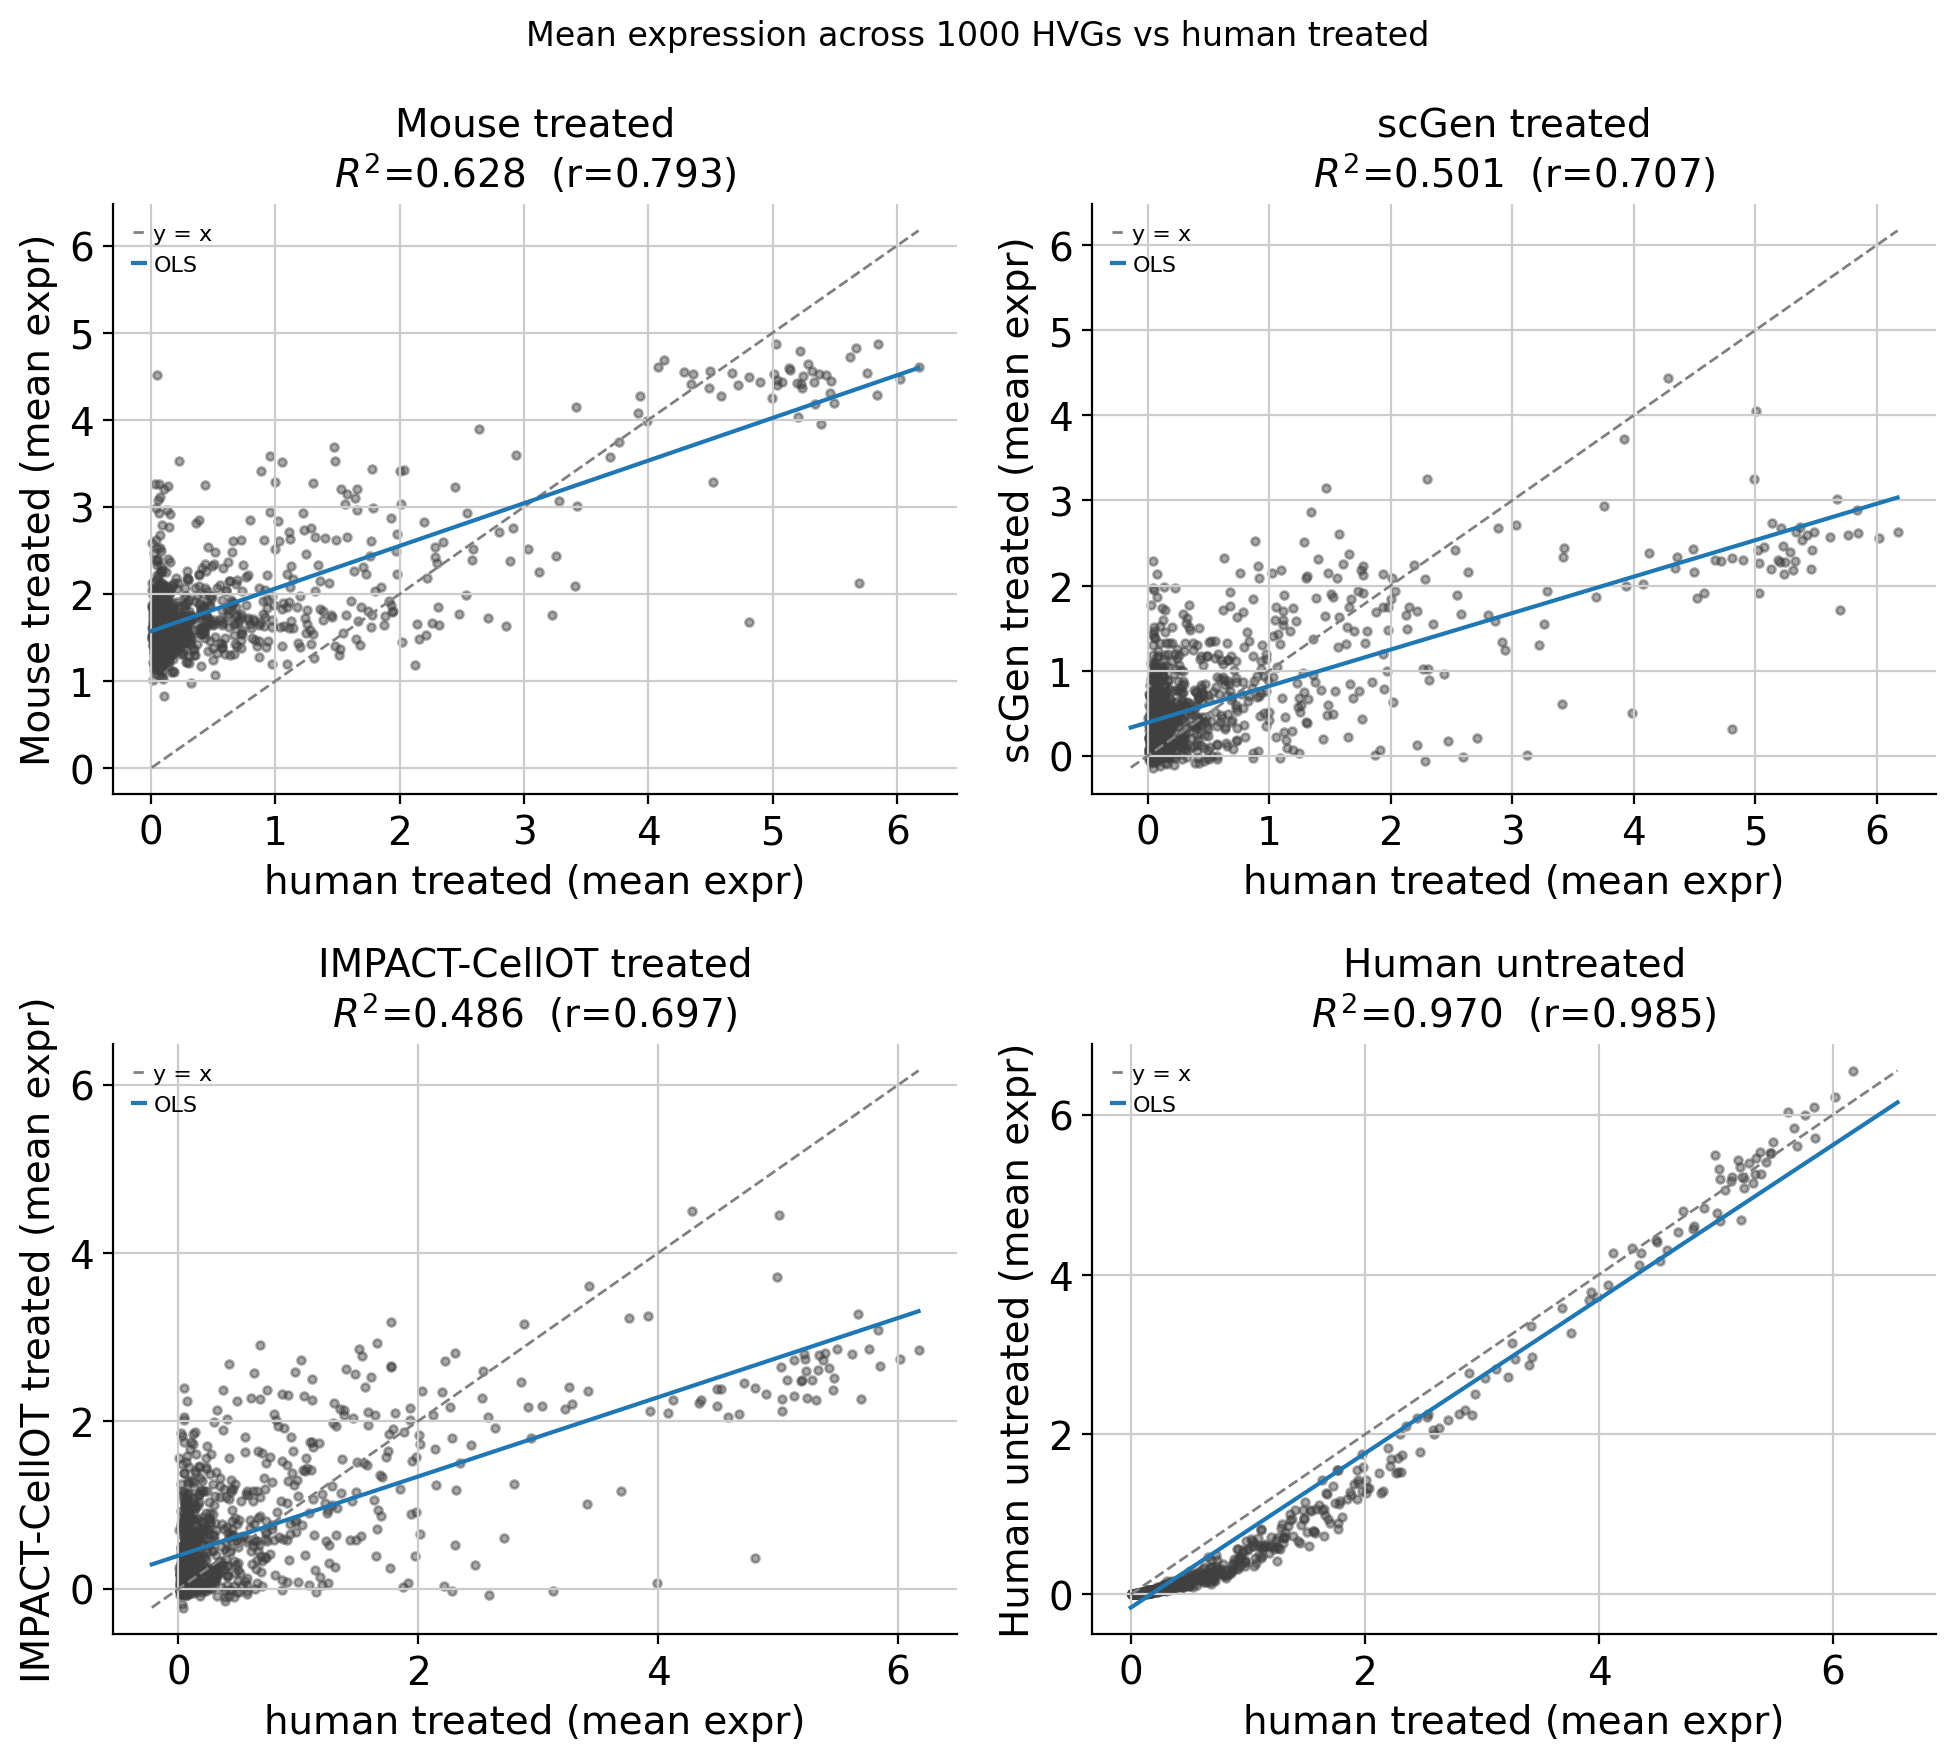

(                 mouse_control  mouse_treated  human_untreated  human_treated  \
 ensg                                                                            
 ENSG00000164047       2.810731       3.256903         0.006320       0.035074   
 ENSG00000143546       3.884265       3.988301         3.717879       3.986416   
 ENSG00000111341       0.937767       1.474503         0.008235       0.049162   
 ENSG00000163631       0.700905       1.635718         0.017978       0.121647   
 ENSG00000170323       0.619141       1.559378         0.014639       0.120617   
 ...                        ...            ...              ...            ...   
 ENSG00000113088       0.500905       1.905827         0.007354       0.049584   
 ENSG00000198755       4.350559       4.275556         4.305718       4.580445   
 ENSG00000171791       1.271653       2.851119         0.231336       0.796646   
 ENSG00000116717       0.980743       2.068841         0.102156       0.271732   
 ENSG00000055957

In [34]:
from scipy.stats import pearsonr, spearmanr

# Stable column order for the mean table
MEAN_COLS = [
    ("mouse", "control", "mouse_control"),
    ("mouse", "treated", "mouse_treated"),
    ("human", "control", "human_untreated"),
    ("human", "treated", "human_treated"),
    ("scgen", "control", "scgen_control"),
    ("scgen", "treated", "scgen_treated"),
    ("impact_cellot", "control", "impact_control"),
    ("impact_cellot", "treated", "impact_treated"),
]

# Shared gene axis (same as joint UMAP when available)
if "ref_genes" in globals():
    genes = list(ref_genes)
else:
    gene_sets = [set(a.var_names) for a in adatas.values()]
    genes = [g for g in next(iter(adatas.values())).var_names if g in set.intersection(*gene_sets)]


def _gene_means(adata, gene_list):
    a = _as_log_expression(adata)[:, gene_list].copy()
    X = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    return np.asarray(X, dtype=float).mean(axis=0)


mean_expr = pd.DataFrame(index=pd.Index(genes, name="ensg"))
for source, condition, col in MEAN_COLS:
    key = (source, condition)
    if key not in adatas:
        print(f"missing {key}, skip {col}")
        continue
    mean_expr[col] = _gene_means(adatas[key], genes)

print(f"mean_expr: {mean_expr.shape[0]} genes × {mean_expr.shape[1]} conditions")
display(mean_expr.head())

# Feature-wise (across genes) agreement with human_treated
TARGET = "human_treated"
COMPARATORS = [
    ("mouse_treated", "Mouse treated"),
    ("scgen_treated", "scGen treated"),
    ("impact_treated", "IMPACT-CellOT treated"),
    ("human_untreated", "Human untreated"),
]

y = mean_expr[TARGET].to_numpy(dtype=float)
rows = []
for col, label in COMPARATORS:
    x = mean_expr[col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    r, p = pearsonr(x[mask], y[mask])
    rho, p_s = spearmanr(x[mask], y[mask])
    # R^2 of predicting y from x (Pearson r^2 for linear association)
    ss_tot = np.sum((y[mask] - y[mask].mean()) ** 2)
    # OLS: y ~ a + b x
    b = np.cov(x[mask], y[mask], ddof=0)[0, 1] / (np.var(x[mask]) + 1e-12)
    a0 = y[mask].mean() - b * x[mask].mean()
    yhat = a0 + b * x[mask]
    r2_ols = 1.0 - np.sum((y[mask] - yhat) ** 2) / (ss_tot + 1e-12)
    rows.append(
        {
            "comparator": label,
            "column": col,
            "n_genes": int(mask.sum()),
            "pearson_r": float(r),
            "pearson_r2": float(r ** 2),
            "ols_r2": float(r2_ols),
            "spearman_rho": float(rho),
            "pearson_p": float(p),
        }
    )

r2_table = pd.DataFrame(rows)
print("Feature-wise agreement of mean expression vs human_treated")
display(r2_table)

# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
for ax, (col, label), row in zip(axes, COMPARATORS, rows):
    x = mean_expr[col].to_numpy(dtype=float)
    ax.scatter(y, x, s=8, alpha=0.45, c="0.25", rasterized=True)
    lims = [
        min(np.nanmin(x), np.nanmin(y)),
        max(np.nanmax(x), np.nanmax(y)),
    ]
    ax.plot(lims, lims, ls="--", c="0.5", lw=1, label="y = x")
    # regression of comparator on human_treated (for display)
    mask = np.isfinite(x) & np.isfinite(y)
    b = np.cov(y[mask], x[mask], ddof=0)[0, 1] / (np.var(y[mask]) + 1e-12)
    a0 = x[mask].mean() - b * y[mask].mean()
    xs = np.linspace(lims[0], lims[1], 50)
    ax.plot(xs, a0 + b * xs, c="C0", lw=1.5, label="OLS")
    ax.set_xlabel("human treated (mean expr)")
    ax.set_ylabel(f"{label} (mean expr)")
    ax.set_title(f"{label}\n$R^2$={row['pearson_r2']:.3f}  (r={row['pearson_r']:.3f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Mean expression across 1000 HVGs vs human treated", fontsize=12)
fig.tight_layout()
plt.show()

mean_expr, r2_table


### Top 100 BCG-associated genes (human) — restricted $R^2$

Rank atlas HVGs by association with BCG in **human** data (|mean treated − untreated|, with Mann–Whitney $p$). Take the top 100, then recompute feature-wise $R^2$ vs `human_treated` on that subset only.


Top 100 BCG-associated genes in human (by |Δ mean|)


,ensg,mean_untreated,mean_treated,delta_treated_minus_untreated,abs_delta,mw_p,rank
0,ENSG00000119535,0.819784,1.766745,0.946961,0.946961,3.456097e-96,1
1,ENSG00000175471,0.606119,1.523292,0.917173,0.917173,3.279627e-95,2
2,ENSG00000198673,0.731613,1.647665,0.916052,0.916052,5.503275e-95,3
3,ENSG00000067082,0.891971,1.772398,0.880427,0.880427,1.496041e-74,4
4,ENSG00000008083,1.264208,2.138447,0.874239,0.874239,5.048633e-95,5
5,ENSG00000008394,1.296656,2.151687,0.855031,0.855031,3.375361e-95,6
6,ENSG00000179097,0.415531,1.249327,0.833796,0.833796,2.001853e-94,7
7,ENSG00000100234,0.971649,1.802658,0.831009,0.831009,1.103181e-89,8
8,ENSG00000172260,0.636680,1.447332,0.810652,0.810652,1.054536e-92,9
9,ENSG00000197746,0.767648,1.577877,0.810229,0.810229,4.128264e-95,10


... 100 genes total; |Δ| range 0.522 – 0.947
Feature-wise R^2 vs human_treated on top 100 BCG-associated genes


,comparator,column,n_genes,gene_set,pearson_r,pearson_r2,ols_r2,spearman_rho,pearson_p
0,Mouse treated,mouse_treated,100,top100_bcg_assoc_human,0.426499,0.181901,0.181901,0.297510,9.661386e-06
1,scGen treated,scgen_treated,100,top100_bcg_assoc_human,0.262681,0.069001,0.069001,0.220150,8.282717e-03
2,IMPACT-CellOT treated,impact_treated,100,top100_bcg_assoc_human,0.220854,0.048776,0.048776,0.163612,2.723633e-02
3,Human untreated,human_untreated,100,top100_bcg_assoc_human,0.988882,0.977887,0.977887,0.987207,6.275923e-83


Comparison to all 1000 HVGs


,comparator,r2_all_1000,r2_top100_bcg
0,Mouse treated,0.628441,0.181901
1,scGen treated,0.500532,0.069001
2,IMPACT-CellOT treated,0.485743,0.048776
3,Human untreated,0.970376,0.977887


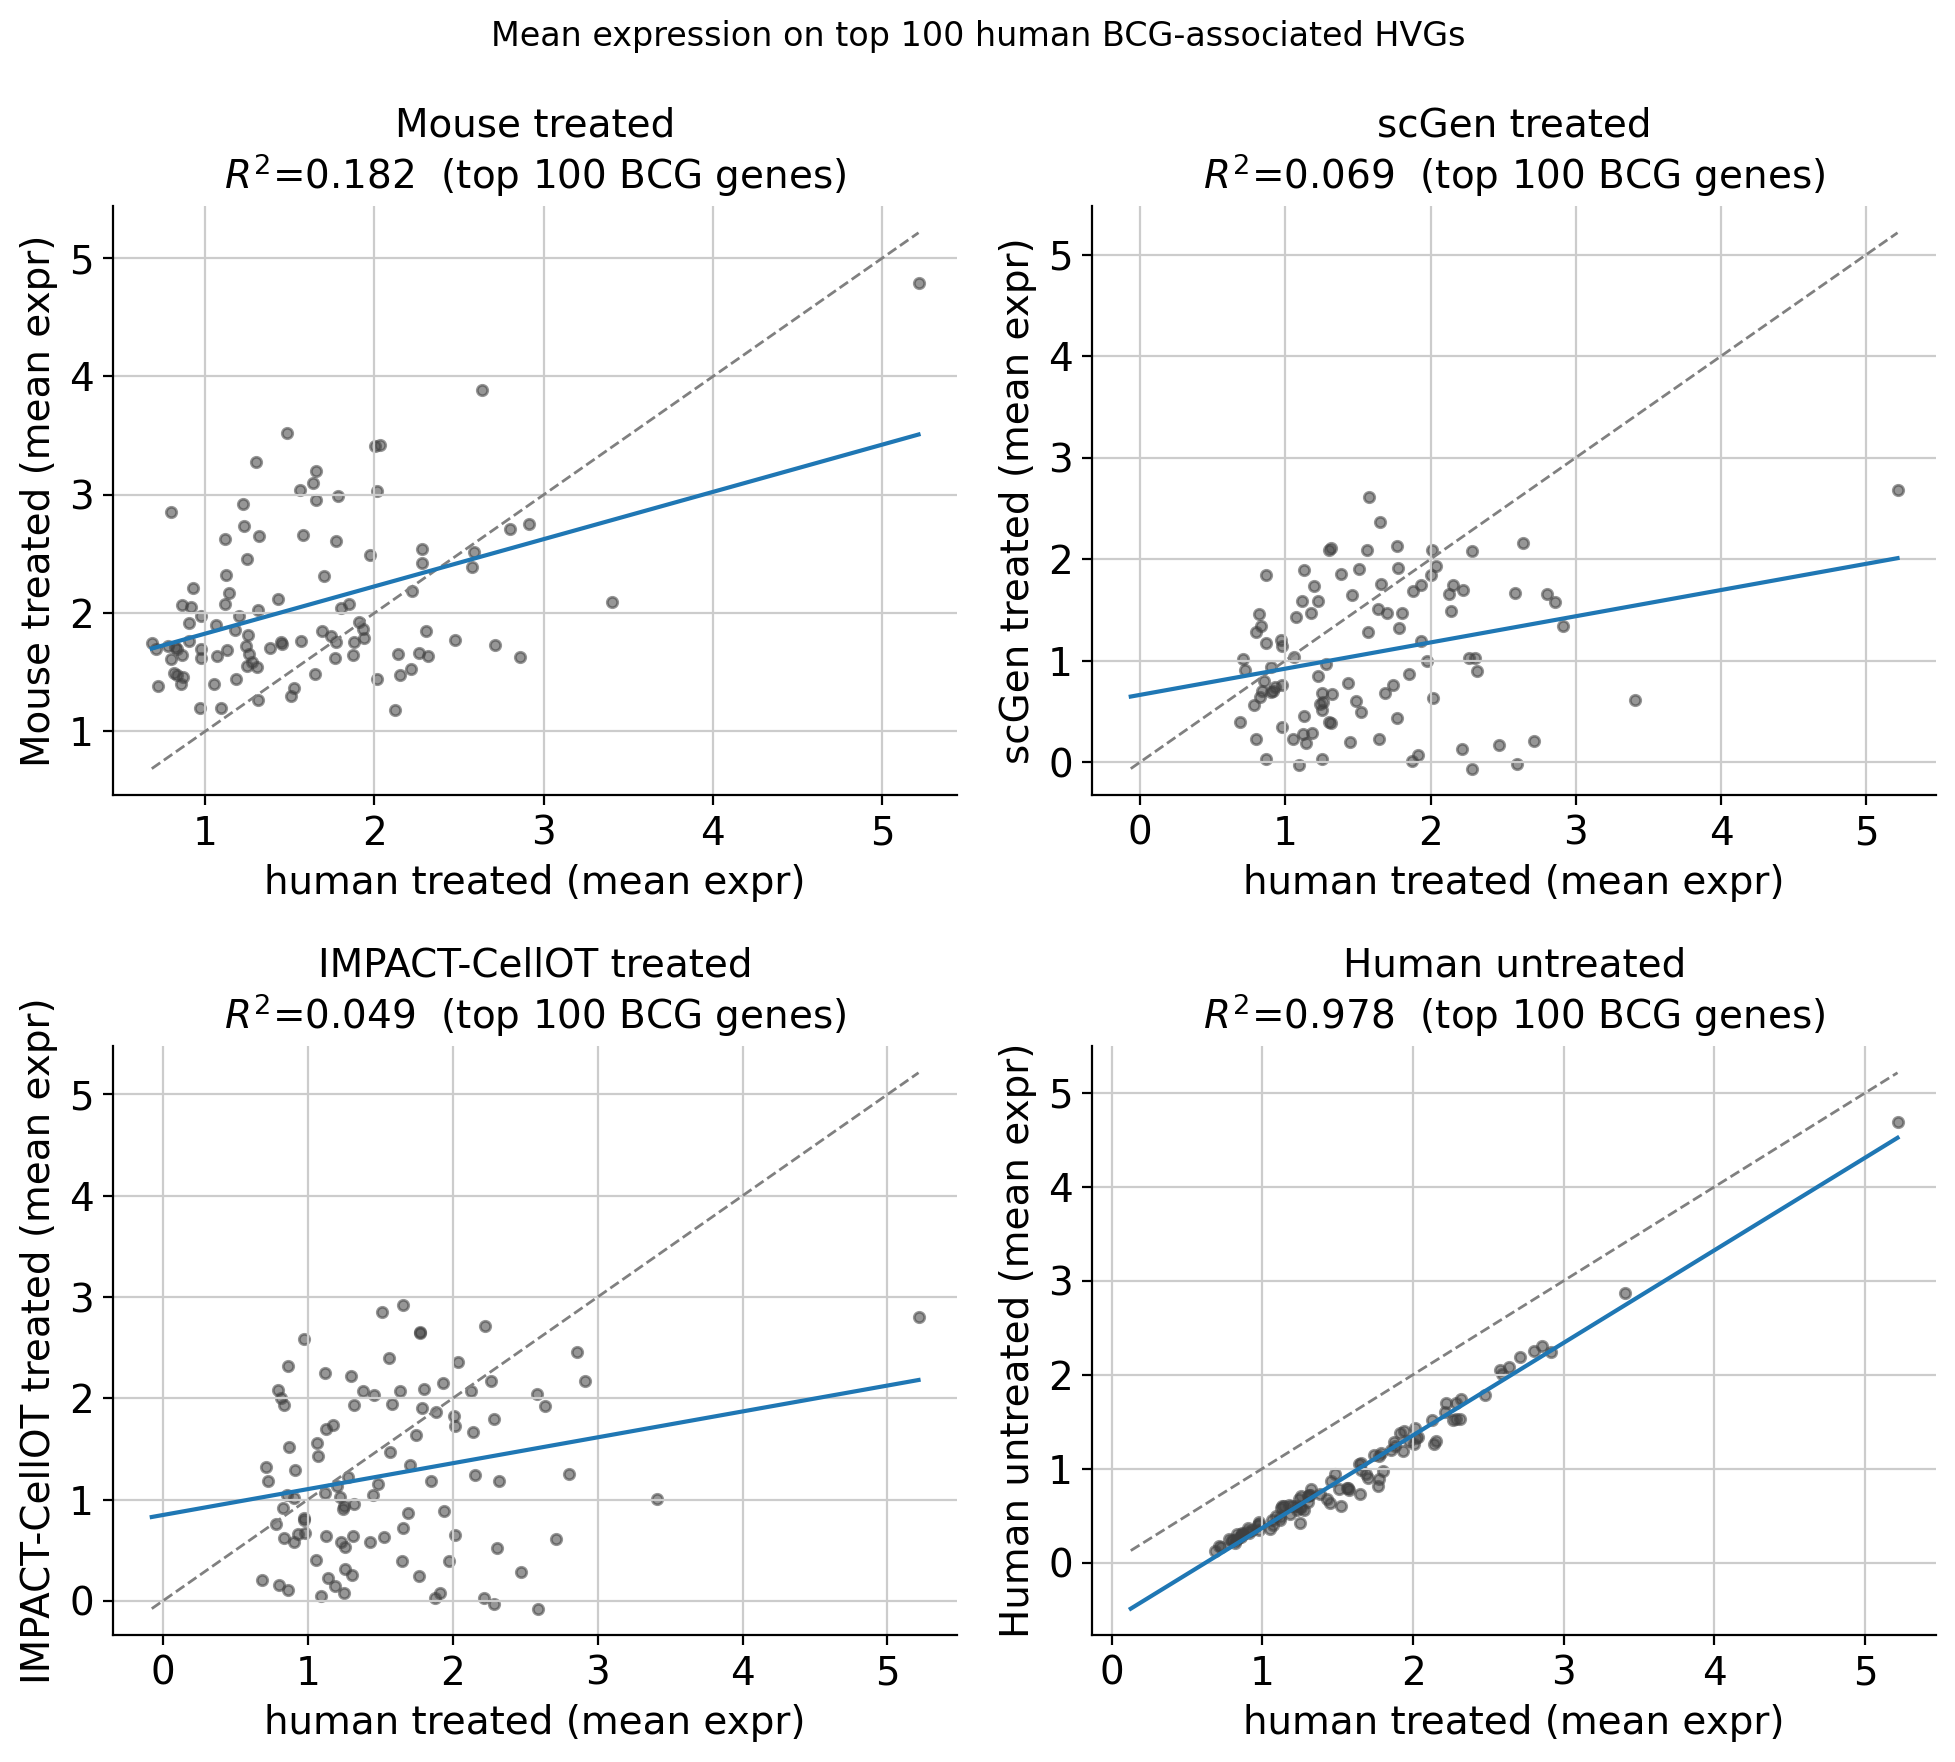

(               ensg  mean_untreated  mean_treated  \
 0   ENSG00000119535        0.819784      1.766745   
 1   ENSG00000175471        0.606119      1.523292   
 2   ENSG00000198673        0.731613      1.647665   
 3   ENSG00000067082        0.891971      1.772398   
 4   ENSG00000008083        1.264208      2.138447   
 ..              ...             ...           ...   
 95  ENSG00000116191        0.305831      0.833479   
 96  ENSG00000204472        2.185232      2.711801   
 97  ENSG00000135046        2.052599      2.578062   
 98  ENSG00000109452        0.603134      1.127899   
 99  ENSG00000075884        1.698288      2.220473   
 
     delta_treated_minus_untreated  abs_delta          mw_p  rank  
 0                        0.946961   0.946961  3.456097e-96     1  
 1                        0.917173   0.917173  3.279627e-95     2  
 2                        0.916052   0.916052  5.503275e-95     3  
 3                        0.880427   0.880427  1.496041e-74     4  
 4        

In [35]:
from scipy.stats import mannwhitneyu

N_TOP_BCG = 100
hu_ctrl = _as_log_expression(adatas[("human", "control")])[:, mean_expr.index].copy()
hu_trt = _as_log_expression(adatas[("human", "treated")])[:, mean_expr.index].copy()

X_ctrl = hu_ctrl.X.toarray() if issparse(hu_ctrl.X) else np.asarray(hu_ctrl.X, dtype=float)
X_trt = hu_trt.X.toarray() if issparse(hu_trt.X) else np.asarray(hu_trt.X, dtype=float)

bcg_rows = []
for j, gene in enumerate(mean_expr.index.astype(str)):
    xc = np.asarray(X_ctrl[:, j], dtype=float).ravel()
    xt = np.asarray(X_trt[:, j], dtype=float).ravel()
    delta = float(xt.mean() - xc.mean())
    # skip all-zero / constant genes
    if np.allclose(xc, xc[0]) and np.allclose(xt, xt[0]) and xc[0] == xt[0]:
        p = 1.0
    else:
        p = float(mannwhitneyu(xt, xc, alternative="two-sided").pvalue)
    bcg_rows.append(
        {
            "ensg": gene,
            "mean_untreated": float(xc.mean()),
            "mean_treated": float(xt.mean()),
            "delta_treated_minus_untreated": delta,
            "abs_delta": abs(delta),
            "mw_p": p,
        }
    )

bcg_assoc = pd.DataFrame(bcg_rows).sort_values(
    ["abs_delta", "mw_p"], ascending=[False, True]
).reset_index(drop=True)
bcg_assoc["rank"] = np.arange(1, len(bcg_assoc) + 1)
bcg_top100 = bcg_assoc.head(N_TOP_BCG).copy()
top100_genes = bcg_top100["ensg"].tolist()

print(f"Top {N_TOP_BCG} BCG-associated genes in human (by |Δ mean|)")
display(bcg_top100.head(20))
print(f"... {N_TOP_BCG} genes total; |Δ| range {bcg_top100['abs_delta'].min():.3g} – {bcg_top100['abs_delta'].max():.3g}")

# R^2 on this gene subset only
mean_expr_top100 = mean_expr.loc[top100_genes]
y = mean_expr_top100[TARGET].to_numpy(dtype=float)
rows_top = []
for col, label in COMPARATORS:
    x = mean_expr_top100[col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    r, p = pearsonr(x[mask], y[mask])
    rho, _ = spearmanr(x[mask], y[mask])
    ss_tot = np.sum((y[mask] - y[mask].mean()) ** 2)
    b = np.cov(x[mask], y[mask], ddof=0)[0, 1] / (np.var(x[mask]) + 1e-12)
    a0 = y[mask].mean() - b * x[mask].mean()
    yhat = a0 + b * x[mask]
    r2_ols = 1.0 - np.sum((y[mask] - yhat) ** 2) / (ss_tot + 1e-12)
    rows_top.append(
        {
            "comparator": label,
            "column": col,
            "n_genes": int(mask.sum()),
            "gene_set": f"top{N_TOP_BCG}_bcg_assoc_human",
            "pearson_r": float(r),
            "pearson_r2": float(r ** 2),
            "ols_r2": float(r2_ols),
            "spearman_rho": float(rho),
            "pearson_p": float(p),
        }
    )

r2_table_top100 = pd.DataFrame(rows_top)
# Side-by-side with all-gene R^2
r2_compare = r2_table[["comparator", "pearson_r2"]].rename(columns={"pearson_r2": "r2_all_1000"}).merge(
    r2_table_top100[["comparator", "pearson_r2"]].rename(columns={"pearson_r2": f"r2_top{N_TOP_BCG}_bcg"}),
    on="comparator",
)
print(f"Feature-wise R^2 vs human_treated on top {N_TOP_BCG} BCG-associated genes")
display(r2_table_top100)
print("Comparison to all 1000 HVGs")
display(r2_compare)

# Scatters on top-100 genes
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
for ax, (col, label), row in zip(axes, COMPARATORS, rows_top):
    x = mean_expr_top100[col].to_numpy(dtype=float)
    ax.scatter(y, x, s=14, alpha=0.55, c="0.25", rasterized=True)
    lims = [min(np.nanmin(x), np.nanmin(y)), max(np.nanmax(x), np.nanmax(y))]
    ax.plot(lims, lims, ls="--", c="0.5", lw=1)
    mask = np.isfinite(x) & np.isfinite(y)
    b = np.cov(y[mask], x[mask], ddof=0)[0, 1] / (np.var(y[mask]) + 1e-12)
    a0 = x[mask].mean() - b * y[mask].mean()
    xs = np.linspace(lims[0], lims[1], 50)
    ax.plot(xs, a0 + b * xs, c="C0", lw=1.5)
    ax.set_xlabel("human treated (mean expr)")
    ax.set_ylabel(f"{label} (mean expr)")
    ax.set_title(f"{label}\n$R^2$={row['pearson_r2']:.3f}  (top {N_TOP_BCG} BCG genes)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(f"Mean expression on top {N_TOP_BCG} human BCG-associated HVGs", fontsize=12)
fig.tight_layout()
plt.show()

bcg_top100, r2_table_top100, r2_compare


## Differential pathway analysis

Compare **untreated vs treated** for **mouse**, **human**, **scGen**, and **IMPACT-CellOT** on 14 Hallmark gene sets (order in `PATHWAYS`): Oxidative phosphorylation, TNFA signaling via NF-κB, Hypoxia, ROS pathway, Apoptosis, Allograft rejection, IL-2/STAT5 signaling, Myc targets V1/V2, DNA repair, EMT, UV response up, Heme metabolism, and KRAS signaling Dn.

Human Hallmark symbols → ENSG (Cell Ranger GTF). The same human pathway ENSGs are scored on every source (mouse already on ENSG ortholog / atlas-HVG axis). Per-cell `sc.tl.score_genes` on genes present on the 1000-HVG axis, then two-sided Mann–Whitney U. Sparse coverage (e.g. OXPHOS) makes some scores underpowered.


In [36]:
import urllib.request

from anndata import concat as ad_concat
from scipy.stats import mannwhitneyu


def _strip_ensg_version(name: str) -> str:
    name = str(name)
    if name.startswith("ENS") and name.count(".") == 1:
        return name.split(".")[0]
    return name


def _load_hallmark_text(path: str, url: str) -> str:
    p = Path(path)
    if p.exists() and p.stat().st_size > 0:
        return p.read_text()
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as resp:
        text = resp.read().decode("utf-8")
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(text)
    return text


def _parse_hallmark(text: str) -> dict[str, list[str]]:
    sets = {}
    for line in text.splitlines():
        parts = line.split("\t")
        if not parts or not parts[0].strip():
            continue
        sets[parts[0].strip()] = [g.strip() for g in parts[2:] if g.strip()]
    return sets


def _gtf_symbol_to_ensg(gtf_path: str) -> dict[str, str]:
    mapping = {}
    with open(gtf_path) as fh:
        for line in fh:
            if line.startswith("#") or "\tgene\t" not in line:
                continue
            attrs = line.split("\t")[8]
            gid = gname = None
            for tok in attrs.strip().split(";"):
                tok = tok.strip()
                if tok.startswith("gene_id"):
                    gid = tok.split('"')[1].split(".")[0]
                elif tok.startswith("gene_name"):
                    gname = tok.split('"')[1]
            if gid and gname and gname not in mapping:
                mapping[gname] = gid
    return mapping


def _norm_set_name(s: str) -> str:
    s = s.lower().replace("il-2", "il2").replace("il–2", "il2")
    s = s.replace("tnf-alpha", "tnfa").replace("tnfa", "tnfa").replace("nf-kb", "nfkb").replace("nf-κb", "nfkb")
    for ch in "/-_κ":
        s = s.replace(ch, " ")
    return " ".join(s.split())


def _match_set_name(all_names, want: str) -> str:
    want_n = _norm_set_name(want)
    # exact normalized match
    for name in all_names:
        if _norm_set_name(name) == want_n:
            return name
    # substring fallback
    for name in all_names:
        cand = _norm_set_name(name)
        if want_n in cand or cand in want_n:
            return name
    raise KeyError(f"Could not find Hallmark set matching {want!r}. Available: {sorted(all_names)}")


# Human pathways only: symbols → ENSG. Mouse data already uses these ENSG ortholog columns.
hallmark = _parse_hallmark(_load_hallmark_text(HALLMARK_PATH, HALLMARK_URL))
sym2ensg = _gtf_symbol_to_ensg(GTF_PATH)

# Optional: confirm one2one ortholog coverage for pathway ENSGs (mouse was projected via this map)
ortho_df = pd.read_csv(ORTHO_CACHE)
if "orthology_type" in ortho_df.columns:
    ortho_df = ortho_df[ortho_df["orthology_type"] == "ortholog_one2one"].copy()
ortho_df["human_ensembl_id"] = ortho_df["human_ensembl_id"].astype(str).map(_strip_ensg_version)
ENSG_WITH_MOUSE_ORTHO = set(ortho_df["human_ensembl_id"])

pathway_symbols = {}
pathway_ensg = {}
for key, want_name in PATHWAYS:
    gmt_name = _match_set_name(hallmark.keys(), want_name)
    symbols = list(dict.fromkeys(hallmark[gmt_name]))
    ensgs = [sym2ensg[s] for s in symbols if s in sym2ensg]
    pathway_symbols[key] = symbols
    pathway_ensg[key] = ensgs
    n_ortho = sum(e in ENSG_WITH_MOUSE_ORTHO for e in ensgs)
    print(
        f"{want_name}  gmt={gmt_name!r}  symbols={len(symbols)}  "
        f"mapped_ensg={len(ensgs)}  with_mouse_one2one={n_ortho}"
    )


def genes_on_axis(adata, ensgs):
    raw_by_stripped = {}
    for name in adata.var_names.astype(str):
        raw_by_stripped.setdefault(_strip_ensg_version(name), name)
    return [raw_by_stripped[e] for e in ensgs if e in raw_by_stripped]


coverage_rows = []
for source in PATHWAY_SOURCES:
    if (source, "control") not in adatas:
        continue
    ref = adatas[(source, "control")]
    for key, want_name in PATHWAYS:
        present = genes_on_axis(ref, pathway_ensg[key])
        coverage_rows.append(
            {
                "source": source,
                "pathway": want_name,
                "n_in_set": len(pathway_symbols[key]),
                "n_mapped_ensg": len(pathway_ensg[key]),
                "n_on_hvg_axis": len(present),
                "frac_on_axis": len(present) / max(len(pathway_symbols[key]), 1),
            }
        )
coverage = pd.DataFrame(coverage_rows)
display(coverage)
if (coverage["n_on_hvg_axis"] < 10).any():
    print("Some sets have very few genes on the 1000-HVG axis; those scores are noisy.")


Oxidative Phosphorylation  gmt='Oxidative Phosphorylation'  symbols=200  mapped_ensg=200  with_mouse_one2one=184
TNF-alpha Signaling via NF-kB  gmt='TNF-alpha Signaling via NF-kB'  symbols=200  mapped_ensg=200  with_mouse_one2one=190
Hypoxia  gmt='Hypoxia'  symbols=200  mapped_ensg=200  with_mouse_one2one=184
Reactive Oxygen Species Pathway  gmt='Reactive Oxygen Species Pathway'  symbols=49  mapped_ensg=49  with_mouse_one2one=40
Apoptosis  gmt='Apoptosis'  symbols=161  mapped_ensg=159  with_mouse_one2one=149
Allograft Rejection  gmt='Allograft Rejection'  symbols=200  mapped_ensg=196  with_mouse_one2one=173
IL-2/STAT5 Signaling  gmt='IL-2/STAT5 Signaling'  symbols=199  mapped_ensg=199  with_mouse_one2one=182
Myc Targets V1  gmt='Myc Targets V1'  symbols=200  mapped_ensg=196  with_mouse_one2one=177
Myc Targets V2  gmt='Myc Targets V2'  symbols=58  mapped_ensg=58  with_mouse_one2one=56
DNA Repair  gmt='DNA Repair'  symbols=150  mapped_ensg=150  with_mouse_one2one=130
Epithelial Mesenchym

,source,pathway,n_in_set,n_mapped_ensg,n_on_hvg_axis,frac_on_axis
0,mouse,Oxidative Phosphorylation,200,200,3,0.015000
1,mouse,TNF-alpha Signaling via NF-kB,200,200,69,0.345000
2,mouse,Hypoxia,200,200,51,0.255000
3,mouse,Reactive Oxygen Species Pathway,49,49,8,0.163265
4,mouse,Apoptosis,161,159,44,0.273292
5,mouse,Allograft Rejection,200,196,47,0.235000
6,mouse,IL-2/STAT5 Signaling,199,199,35,0.175879
7,mouse,Myc Targets V1,200,196,5,0.025000
8,mouse,Myc Targets V2,58,58,1,0.017241
9,mouse,DNA Repair,150,150,2,0.013333


Some sets have very few genes on the 1000-HVG axis; those scores are noisy.


In [37]:
def _bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    q = np.empty(n, dtype=float)
    prev = 1.0
    for i, idx in enumerate(order[::-1]):
        rank = n - i
        val = min(prev, p[idx] * n / rank)
        q[idx] = val
        prev = val
    return np.clip(q, 0, 1)


def _to_1d(x):
    if issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=float).ravel()


SOURCE_LABEL = {
    "mouse": "Mouse",
    "human": "Human",
    "scgen": "scGen",
    "impact_cellot": "IMPACT-CellOT",
}

scored = {}
stat_rows = []
gene_delta_rows = []

for source in PATHWAY_SOURCES:
    if (source, "control") not in adatas or (source, "treated") not in adatas:
        print(f"skip {source}: missing control/treated")
        continue
    # Log-normalize from counts when present so mouse/human match prediction-like scales for scoring
    ctrl = _as_log_expression(adatas[(source, "control")])
    trt = _as_log_expression(adatas[(source, "treated")])
    adata_m = ad_concat([ctrl, trt], join="inner", index_unique="-")
    adata_m.obs["pathway_source"] = source

    for key, want_name in PATHWAYS:
        # Always human pathway ENSGs (mouse already on ENSG ortholog axis)
        present = genes_on_axis(adata_m, pathway_ensg[key])
        score_name = f"score_{key}"
        if len(present) == 0:
            adata_m.obs[score_name] = np.nan
            stat_rows.append(
                {
                    "model": source,
                    "pathway": want_name,
                    "n_genes_scored": 0,
                    "n_control": int((adata_m.obs["bcg_condition"] == "control").sum()),
                    "n_treated": int((adata_m.obs["bcg_condition"] == "treated").sum()),
                    "mean_control": np.nan,
                    "mean_treated": np.nan,
                    "delta_treated_minus_control": np.nan,
                    "U": np.nan,
                    "p": np.nan,
                    "cliffs_delta": np.nan,
                }
            )
            continue
        sc.tl.score_genes(adata_m, present, score_name=score_name, use_raw=False)
        scores = adata_m.obs[score_name].to_numpy(dtype=float)
        is_trt = adata_m.obs["bcg_condition"].to_numpy() == "treated"
        x_trt = scores[is_trt]
        x_ctrl = scores[~is_trt]
        u = mannwhitneyu(x_trt, x_ctrl, alternative="two-sided")
        cliffs = (2.0 * u.statistic) / (len(x_trt) * len(x_ctrl)) - 1.0
        stat_rows.append(
            {
                "model": source,
                "pathway": want_name,
                "n_genes_scored": len(present),
                "n_control": int((~is_trt).sum()),
                "n_treated": int(is_trt.sum()),
                "mean_control": float(np.mean(x_ctrl)),
                "mean_treated": float(np.mean(x_trt)),
                "delta_treated_minus_control": float(np.mean(x_trt) - np.mean(x_ctrl)),
                "U": float(u.statistic),
                "p": float(u.pvalue),
                "cliffs_delta": float(cliffs),
            }
        )

        ensg_to_symbol = {}
        for sym in pathway_symbols[key]:
            if sym in sym2ensg:
                ensg_to_symbol[sym2ensg[sym]] = sym
        for var_name in present:
            ensg = _strip_ensg_version(var_name)
            gene_delta_rows.append(
                {
                    "model": source,
                    "pathway": want_name,
                    "gene": ensg_to_symbol.get(ensg, ensg),
                    "ensg": ensg,
                    "mean_control": float(_to_1d(ctrl[:, var_name].X).mean()),
                    "mean_treated": float(_to_1d(trt[:, var_name].X).mean()),
                }
            )

    scored[source] = adata_m

pathway_stats = pd.DataFrame(stat_rows)
pathway_stats["q"] = _bh_fdr(pathway_stats["p"].fillna(1.0))
pathway_stats.loc[pathway_stats["p"].isna(), "q"] = np.nan
pathway_stats["source_label"] = pathway_stats["model"].map(SOURCE_LABEL)
print("Module scores: untreated vs treated (positive delta = higher in treated)")
print("Gene sets: human Hallmark → ENSG for all sources (mouse via ENSG ortholog axis)")
display(pathway_stats)

gene_deltas = pd.DataFrame(gene_delta_rows)
if len(gene_deltas):
    gene_deltas["delta_treated_minus_control"] = gene_deltas["mean_treated"] - gene_deltas["mean_control"]


Module scores: untreated vs treated (positive delta = higher in treated)
Gene sets: human Hallmark → ENSG for all sources (mouse via ENSG ortholog axis)


,model,pathway,n_genes_scored,n_control,n_treated,mean_control,mean_treated,delta_treated_minus_control,U,p,cliffs_delta,q,source_label
0,mouse,Oxidative Phosphorylation,3,387,251,-0.022844,0.043497,0.066341,75962.0,2.074223e-33,0.564018,2.978372e-33,Mouse
1,mouse,TNF-alpha Signaling via NF-kB,69,387,251,0.253969,0.215952,-0.038017,32072.0,4.071968e-13,-0.339654,4.957178e-13,Mouse
2,mouse,Hypoxia,51,387,251,0.022945,0.056932,0.033987,82294.0,9.572486e-50,0.694390,1.729223e-49,Mouse
3,mouse,Reactive Oxygen Species Pathway,8,387,251,-0.028808,0.066438,0.095246,85335.0,8.804725e-59,0.757003,1.760945e-58,Mouse
4,mouse,Apoptosis,44,387,251,-0.012831,0.013880,0.026711,76811.0,2.093382e-35,0.581498,3.168362e-35,Mouse
5,mouse,Allograft Rejection,47,387,251,0.031176,0.104709,0.073533,76945.0,1.000734e-35,0.584257,1.556697e-35,Mouse
6,mouse,IL-2/STAT5 Signaling,35,387,251,-0.079932,-0.036523,0.043409,80206.0,5.468584e-44,0.651400,9.007079e-44,Mouse
7,mouse,Myc Targets V1,5,387,251,1.043749,0.744231,-0.299517,5982.0,3.114633e-78,-0.876834,7.583453e-78,Mouse
8,mouse,Myc Targets V2,1,387,251,-0.081919,-0.129684,-0.047765,40251.0,2.552716e-04,-0.171253,2.749079e-04,Mouse
9,mouse,DNA Repair,2,387,251,0.250824,-0.121347,-0.372172,2207.0,2.294217e-92,-0.954559,8.029758e-92,Mouse


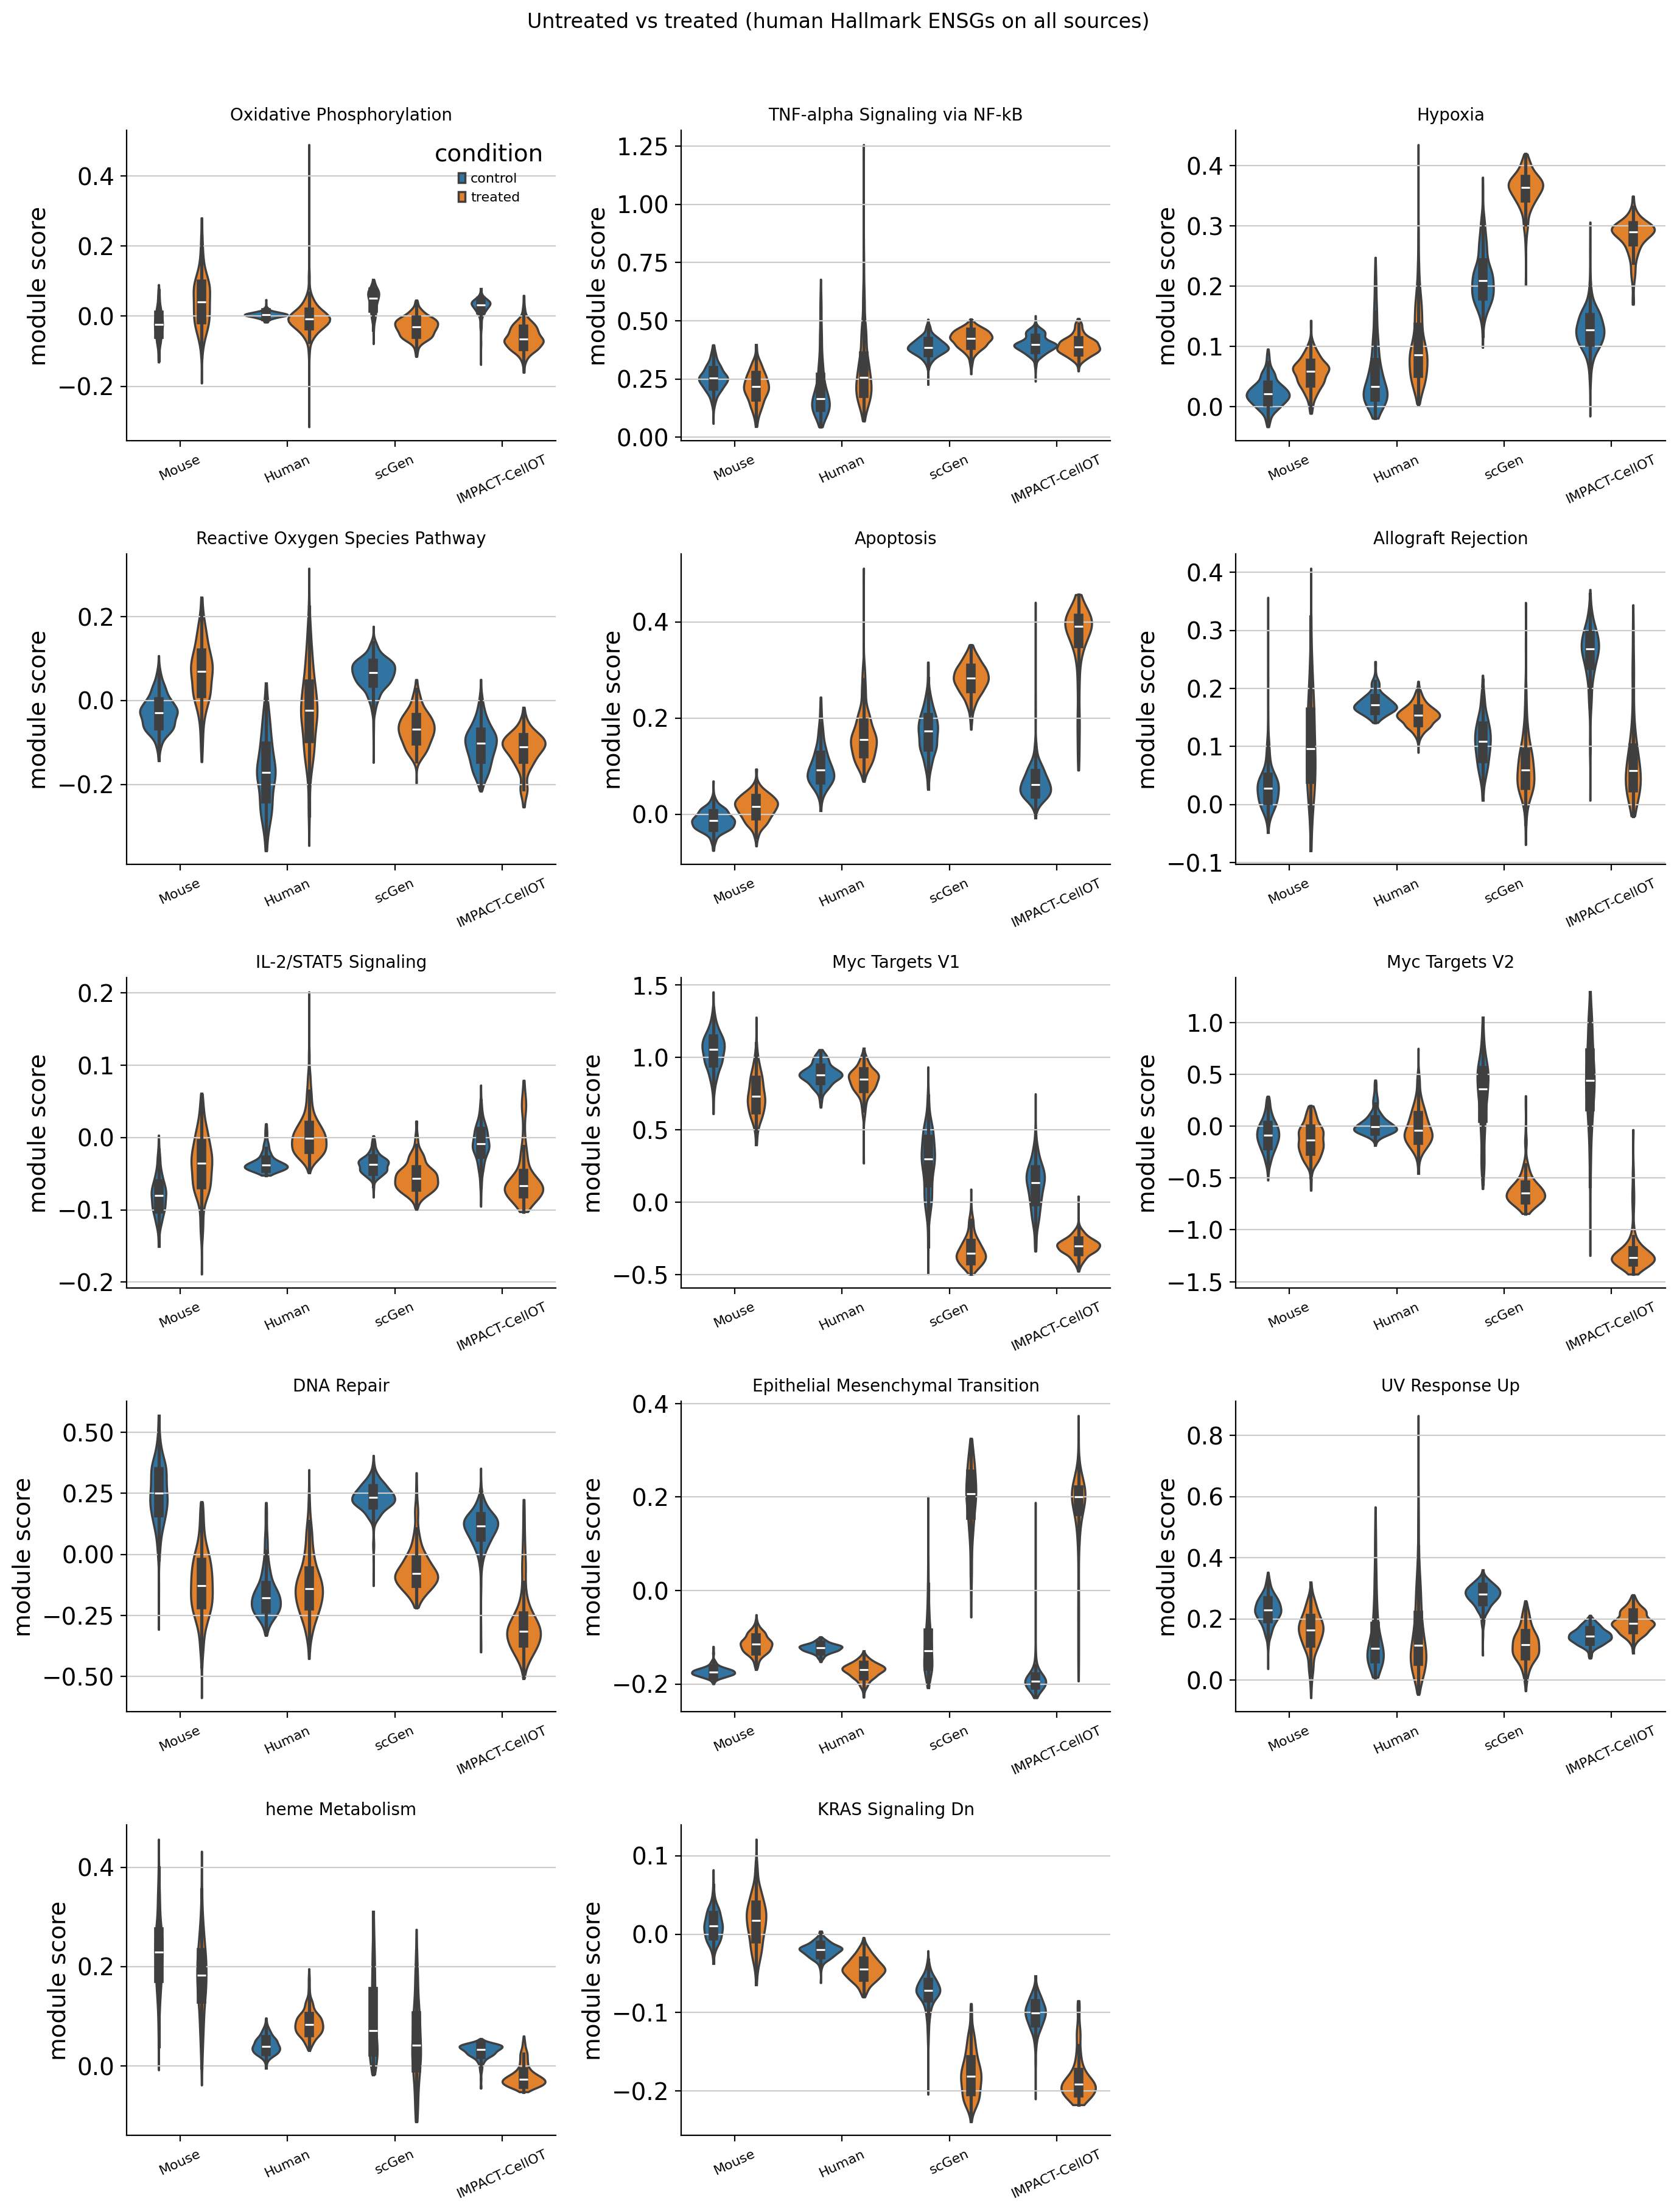

Mean genes on HVG axis per pathway:


pathway,Oxidative Phosphorylation,TNF-alpha Signaling via NF-kB,Hypoxia,Reactive Oxygen Species Pathway,Apoptosis,Allograft Rejection,IL-2/STAT5 Signaling,Myc Targets V1,Myc Targets V2,DNA Repair,Epithelial Mesenchymal Transition,UV Response Up,heme Metabolism,KRAS Signaling Dn
n_on_hvg_axis,3.0,69.0,51.0,8.0,44.0,47.0,35.0,5.0,1.0,2.0,87.0,26.0,23.0,23.0


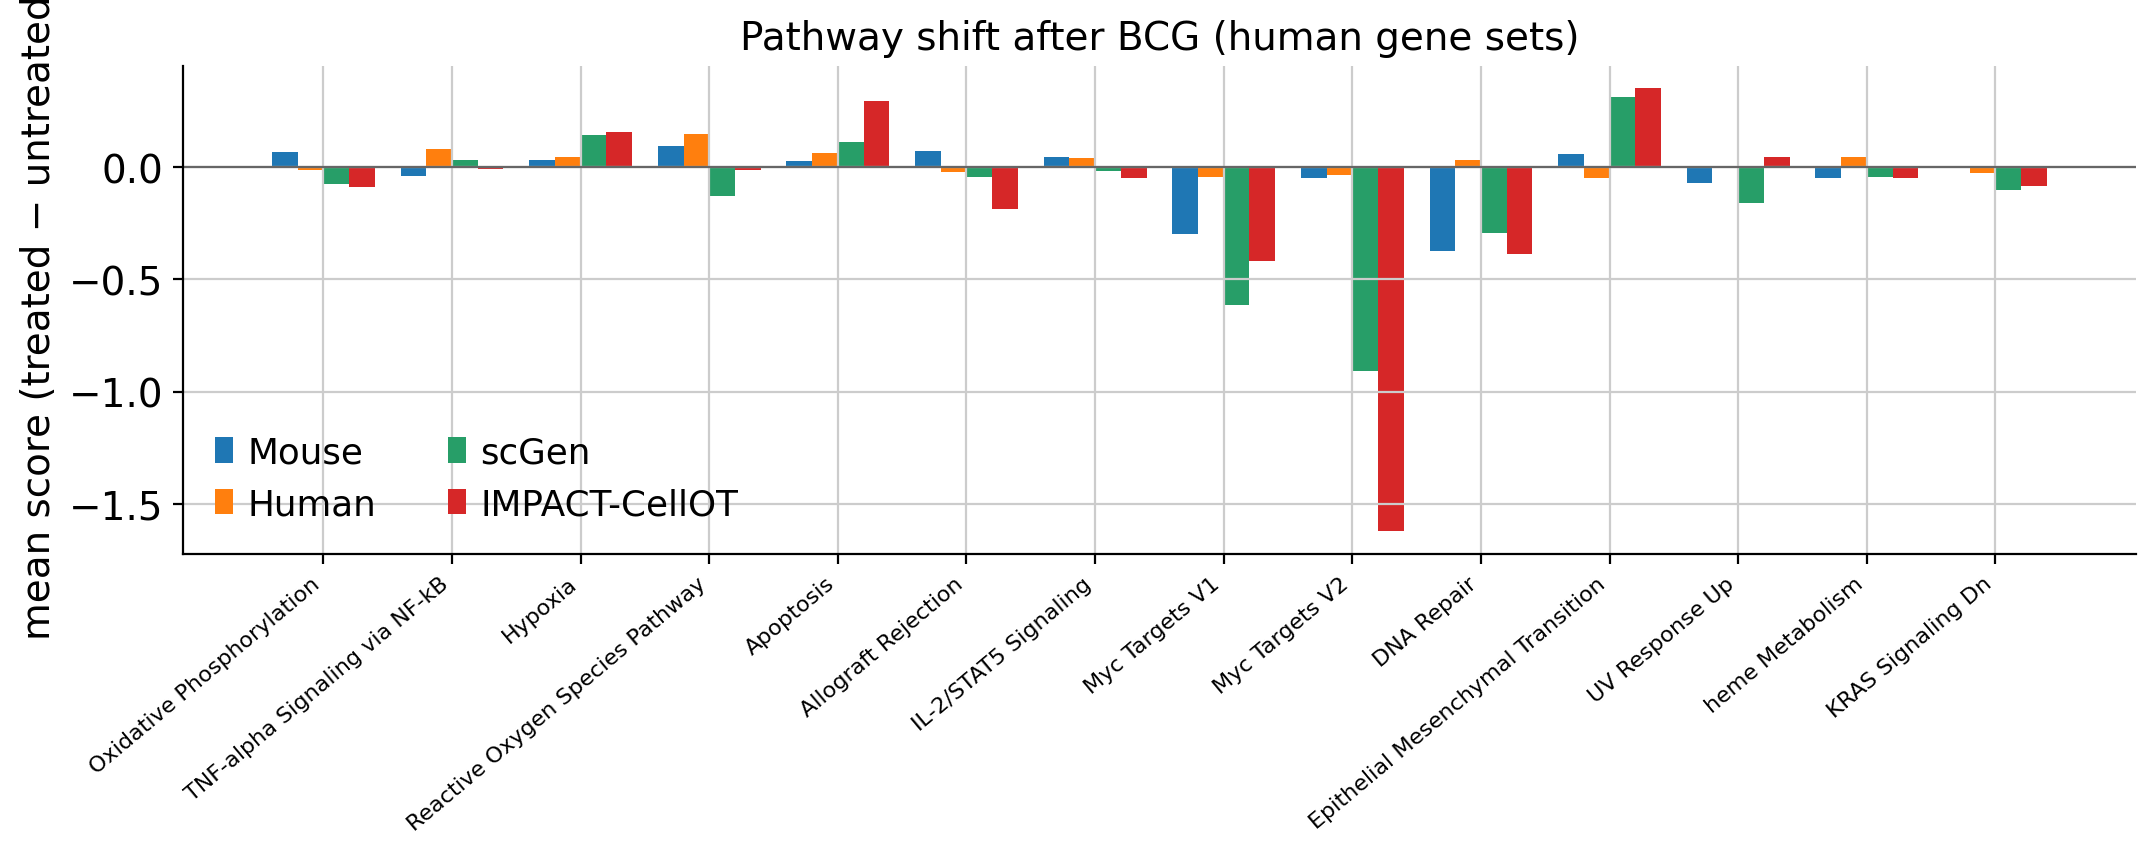

Pathway genes on the HVG axis, mean expression (human symbols / ENSG)


,model,pathway,gene,ensg,mean_control,mean_treated,delta_treated_minus_control
0,human,Allograft Rejection,CTSS,ENSG00000163131,1.197092,1.850561,0.653469
1,human,Allograft Rejection,EREG,ENSG00000124882,1.603474,2.214675,0.611201
2,human,Allograft Rejection,HLA-DRA,ENSG00000204287,1.741621,2.317120,0.575499
3,human,Allograft Rejection,TIMP1,ENSG00000102265,0.452052,0.945107,0.493055
4,human,Allograft Rejection,LCP2,ENSG00000043462,0.238096,0.723593,0.485497
...,...,...,...,...,...,...,...
1691,scgen,heme Metabolism,TSPO2,ENSG00000112212,0.130132,0.110409,-0.019723
1692,scgen,heme Metabolism,AQP3,ENSG00000165272,0.010386,-0.012125,-0.022511
1693,scgen,heme Metabolism,MKRN1,ENSG00000133606,0.785858,0.720293,-0.065564
1694,scgen,heme Metabolism,CA1,ENSG00000133742,0.111386,-0.023250,-0.134636


In [38]:
import seaborn as sns

SOURCE_ORDER = ["Mouse", "Human", "scGen", "IMPACT-CellOT"]
SOURCE_LABEL = {
    "mouse": "Mouse",
    "human": "Human",
    "scgen": "scGen",
    "impact_cellot": "IMPACT-CellOT",
}

n_pw = len(PATHWAYS)
n_cols = 3
n_rows = int(np.ceil(n_pw / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, (key, want_name) in zip(axes, PATHWAYS):
    parts = []
    for source, adata_m in scored.items():
        col = f"score_{key}"
        if col not in adata_m.obs:
            continue
        df = adata_m.obs[["bcg_condition", col]].rename(columns={col: "score"}).copy()
        df["model"] = SOURCE_LABEL.get(source, source)
        parts.append(df)
    plot_df = pd.concat(parts, ignore_index=True)
    order = [s for s in SOURCE_ORDER if s in set(plot_df["model"])]
    sns.violinplot(
        data=plot_df,
        x="model",
        y="score",
        hue="bcg_condition",
        hue_order=["control", "treated"],
        order=order,
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_title(want_name, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("module score")
    ax.tick_params(axis="x", labelrotation=25, labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ax is axes[0]:
        ax.legend(title="condition", frameon=False, fontsize=8)
    elif ax.get_legend() is not None:
        ax.get_legend().remove()

for ax in axes[n_pw:]:
    ax.axis("off")

n_genes = (
    coverage.groupby("pathway")["n_on_hvg_axis"].mean().round(0).astype(int).to_dict()
    if "source" in coverage.columns
    else coverage.set_index("pathway")["n_on_hvg_axis"].to_dict()
)
fig.suptitle("Untreated vs treated (human Hallmark ENSGs on all sources)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

# Compact coverage strip
cov_pivot = coverage.pivot_table(index="pathway", values="n_on_hvg_axis", aggfunc="mean")
cov_pivot = cov_pivot.reindex([name for _, name in PATHWAYS])
print("Mean genes on HVG axis per pathway:")
display(cov_pivot.T)

fig, ax = plt.subplots(figsize=(11, 4.5))
delta_df = pathway_stats.pivot(index="pathway", columns="model", values="delta_treated_minus_control")
delta_df = delta_df.reindex([name for _, name in PATHWAYS])
x = np.arange(len(delta_df.index))
models_plot = [m for m in PATHWAY_SOURCES if m in delta_df.columns]
width = 0.8 / max(len(models_plot), 1)
for i, model in enumerate(models_plot):
    vals = delta_df[model].to_numpy(dtype=float)
    ax.bar(
        x + (i - (len(models_plot) - 1) / 2) * width,
        vals,
        width,
        label=SOURCE_LABEL[model],
    )
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(delta_df.index, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("mean score (treated − untreated)")
ax.set_title("Pathway shift after BCG (human gene sets)")
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

if len(gene_deltas):
    print("Pathway genes on the HVG axis, mean expression (human symbols / ENSG)")
    show = gene_deltas.sort_values(
        ["pathway", "model", "delta_treated_minus_control"], ascending=[True, True, False]
    )
    display(show.reset_index(drop=True))
